####
Credit card fraud detector

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#from google.colab import drive
#drive.mount('/content/drive') in jupyter

In [6]:
df = pd.read_csv("creditcard.csv")

In [7]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


df.shape

In [8]:
df.shape

(284807, 31)

In [9]:
df.isnull().sum() # checking for null values

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [10]:
df.duplicated().sum() # checking for duplicate values   

np.int64(1081)

In [12]:
geniune = df[df.Class == 0]
fraud= df[df.Class ==1]

print(geniune.shape)
print(fraud.shape)

(284315, 31)
(492, 31)


In [13]:
fraud_percentage = fraud.shape[0] / df.shape[0] * 100
fraud_percentage

0.1727485630620034

In [14]:
df['Class'].value_counts(normalize=True)*100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

([<matplotlib.patches.Wedge at 0x12beb076510>,
 [Text(-1.0999838024749575, 0.0059694466019511215, 'Genuine'),
  Text(1.099983802996819, -0.005969350438309128, 'Fraud')],
 [Text(-0.5999911649863404, 0.0032560617828824297, '99.8%'),
  Text(0.5999911652709922, -0.0032560093299867964, '0.2%')])

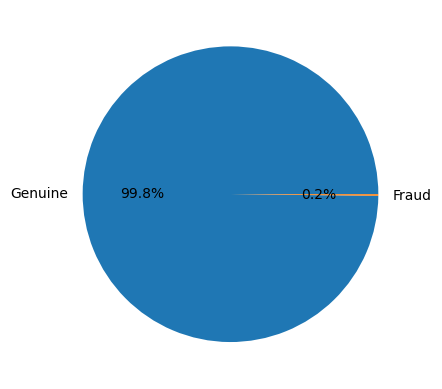

In [15]:
plt.pie(df['Class'].value_counts(), labels=['Genuine', 'Fraud'], autopct='%1.1f%%')

([<matplotlib.axis.XTick at 0x12beb1056d0>,
 [Text(0, 0, 'Genuine'), Text(1, 0, 'Fraud')])

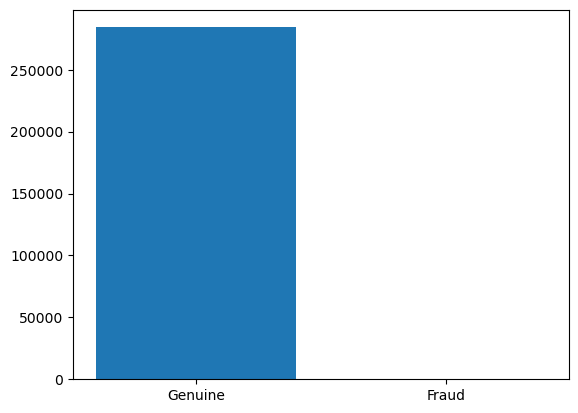

In [17]:
plt.bar(df['Class'].value_counts().index, df['Class'].value_counts().values)
plt.xticks([0, 1], ['Genuine', 'Fraud'])

In [21]:
from sklearn.preprocessing import StandardScaler

In [22]:
se = StandardScaler()

In [23]:
df['NormalizedAmount'] = se.fit_transform(df['Amount'].values.reshape(-1, 1))
print(df['NormalizedAmount'])

0         0.244964
1        -0.342475
2         1.160686
3         0.140534
4        -0.073403
            ...   
284802   -0.350151
284803   -0.254117
284804   -0.081839
284805   -0.313249
284806    0.514355
Name: NormalizedAmount, Length: 284807, dtype: float64


In [24]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,NormalizedAmount
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0.244964
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,-0.342475
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,1.160686
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,0.140534
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,-0.073403
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0,-0.350151
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0,-0.254117
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0,-0.081839
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0,-0.313249


In [35]:
%pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from imblearn.over_sampling import SMOTE


In [30]:
from sklearn.model_selection import train_test_split    

In [27]:
x = df.drop(columns=['Time','Amount','Class'])
x

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,NormalizedAmount
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.244964
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.342475
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.160686
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.140534
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.073403
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,...,1.475829,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,-0.350151
284803,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,...,0.059616,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,-0.254117
284804,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,...,0.001396,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,-0.081839
284805,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,...,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,-0.313249


In [28]:
y = df['Class']
y

0         0
1         0
2         0
3         0
4         0
         ..
284802    0
284803    0
284804    0
284805    0
284806    0
Name: Class, Length: 284807, dtype: int64

In [31]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 24)

In [33]:
y_train

33442     0
4484      0
163091    0
12689     0
163345    0
         ..
224082    0
268644    0
211136    0
899       0
242082    0
Name: Class, Length: 199364, dtype: int64

In [34]:
smote = SMOTE(random_state = 24)
X_train_sm, Y_train_sm = smote.fit_resample(x_train, y_train)

In [36]:
# model building::



from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics  import accuracy_score, classification_report

In [37]:
decision_tree = DecisionTreeClassifier()

decision_tree.fit(X_train_sm,Y_train_sm)

DecisionTreeClassifier()

In [38]:

dt_prediction =decision_tree.predict(x_test)

In [39]:
dt_accuracy = accuracy_score(y_test,dt_prediction)



In [40]:
print(f" decision Tree Accuracy {dt_accuracy}")

 decision Tree Accuracy 0.9977294804723617


In [41]:
print(classification_report(y_test,dt_prediction))

# model says 10 transaction are fraud

#but actually data  7 are fraud

# 7/10 = 0.70

# high precision = model give accurate fraud answers


# 100% precision has correctly identify all normal transaction

# 40% precision has correctly indentify fraud transaction



# recall : how many real frauds data the model caught

# there are 10 real frauds

# model caught only 6

# 6/10 : 0.60    # high recall : catches more fraud


# f1 score : precision + recall

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85287
           1       0.43      0.74      0.54       156

    accuracy                           1.00     85443
   macro avg       0.71      0.87      0.77     85443
weighted avg       1.00      1.00      1.00     85443



In [42]:
# random forest


random_forest = RandomForestClassifier()
random_forest.fit(X_train_sm,Y_train_sm)

RandomForestClassifier()

In [43]:
rf_prediction = random_forest.predict(x_test)

In [44]:
rf_accuracy =  accuracy_score(y_test , rf_prediction)

In [45]:
print(f" the accuaracy achieved by random forest is {rf_accuracy}")

 the accuaracy achieved by random forest is 0.9993797034280163


In [48]:
print(classification_report(y_test ,rf_prediction ))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85287
           1       0.86      0.79      0.82       156

    accuracy                           1.00     85443
   macro avg       0.93      0.89      0.91     85443
weighted avg       1.00      1.00      1.00     85443



In [49]:

#  logistic regression

from sklearn.linear_model import LogisticRegression

In [50]:
log_model = LogisticRegression()

In [51]:
log_model.fit(X_train_sm,Y_train_sm)


LogisticRegression()

In [52]:
log_prediction= log_model.predict(x_test)

In [53]:

log_accuracy = accuracy_score(y_test , log_prediction)

In [54]:
print(f" the log accuracy is {log_accuracy}")

 the log accuracy is 0.9772713973058063


In [55]:
print(classification_report(y_test , log_prediction))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     85287
           1       0.06      0.85      0.12       156

    accuracy                           0.98     85443
   macro avg       0.53      0.92      0.55     85443
weighted avg       1.00      0.98      0.99     85443



In [56]:
# svm with kernel : rbf
# SVM :  SVC : SVR

from sklearn.svm  import SVC



In [57]:
svm_model = SVC(kernel ='rbf')

In [ ]:
svm_predict =svm_model.fit(X_train_sm,Y_train_sm)

In [ ]:
svm_predict = svm_model.predict(x_test)

In [ ]:
print(f" svm accuracy is {accuracy_score(y_test , svm_predict)}" )

In [ ]:
print(f"classfication report {classification_report(y_test , svm_predict)}")print(f"classfication report {classification_report(y_test , svm_predict)}")